# 02 Missing Value Analysis

This notebook studies missingness before imputation and produces lightweight artifacts:

- CSV summary in `../interim`
- Markdown report in `../reports`
- Missing-value figures in `../figures`

No missing values are filled here.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATASET_DIR = Path("..").resolve()
RAW_DIR = DATASET_DIR / "raw"
INTERIM_DIR = DATASET_DIR / "interim"
REPORTS_DIR = DATASET_DIR / "reports"
FIGURES_DIR = DATASET_DIR / "figures"

for directory in [INTERIM_DIR, REPORTS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = RAW_DIR / "GiveMeSomeCredit-training.csv"
TEST_PATH = RAW_DIR / "GiveMeSomeCredit-testing.csv"

In [3]:
train_df = pd.read_csv(TRAIN_PATH).drop(columns=["Unnamed: 0"], errors="ignore")
test_df = pd.read_csv(TEST_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

In [4]:
def missing_report(df, dataset_name):
    return pd.DataFrame({
        "dataset": dataset_name,
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100,
        "dtype": df.dtypes.astype(str),
    }).sort_values("missing_percent", ascending=False)

train_missing = missing_report(train_df, "training")
test_missing = missing_report(test_df, "testing")
missing_summary = pd.concat([train_missing, test_missing])
missing_summary

,dataset,missing_count,missing_percent,dtype
MonthlyIncome,training,29731,19.820667,float64
NumberOfDependents,training,3924,2.616000,float64
SeriousDlqin2yrs,training,0,0.000000,int64
age,training,0,0.000000,int64
RevolvingUtilizationOfUnsecuredLines,training,0,0.000000,float64
DebtRatio,training,0,0.000000,float64
NumberOfTime30-59DaysPastDueNotWorse,training,0,0.000000,int64
NumberOfOpenCreditLinesAndLoans,training,0,0.000000,int64
NumberOfTimes90DaysLate,training,0,0.000000,int64
NumberRealEstateLoansOrLines,training,0,0.000000,int64


In [5]:
focus_cols = ["MonthlyIncome", "NumberOfDependents"]

for col in focus_cols:
    print(f"{col}")
    print(f"  training missing: {train_df[col].isna().sum()} ({train_df[col].isna().mean() * 100:.2f}%)")
    print(f"  testing missing:  {test_df[col].isna().sum()} ({test_df[col].isna().mean() * 100:.2f}%)")

MonthlyIncome
  training missing: 29731 (19.82%)
  testing missing:  20103 (19.81%)
NumberOfDependents
  training missing: 3924 (2.62%)
  testing missing:  2626 (2.59%)


In [6]:
income_missing_profile = train_df.assign(
    MonthlyIncome_missing=train_df["MonthlyIncome"].isna().astype(int)
).groupby("MonthlyIncome_missing").agg({
    "SeriousDlqin2yrs": ["mean", "count"],
    "age": "median",
    "DebtRatio": "median",
    "RevolvingUtilizationOfUnsecuredLines": "median",
    "NumberOfOpenCreditLinesAndLoans": "median",
    "NumberOfDependents": "median",
})

income_missing_profile

SeriousDlqin2yrs            age    DebtRatio  \
                                  mean   count median       median   
MonthlyIncome_missing                                                
0                             0.069486  120269   51.0     0.296023   
1                             0.056137   29731   57.0  1159.000000   

                      RevolvingUtilizationOfUnsecuredLines  \
                                                    median   
MonthlyIncome_missing                                        
0                                                 0.177282   
1                                                 0.081697   

                      NumberOfOpenCreditLinesAndLoans NumberOfDependents  
                                               median             median  
MonthlyIncome_missing                                                     
0                                                 8.0                0.0  
1                                                 6.0                0.0

In [7]:
dependents_missing_profile = train_df.assign(
    NumberOfDependents_missing=train_df["NumberOfDependents"].isna().astype(int)
).groupby("NumberOfDependents_missing").agg({
    "SeriousDlqin2yrs": ["mean", "count"],
    "age": "median",
    "MonthlyIncome": "median",
    "DebtRatio": "median",
    "NumberOfOpenCreditLinesAndLoans": "median",
})

dependents_missing_profile

SeriousDlqin2yrs            age MonthlyIncome  \
                                       mean   count median        median   
NumberOfDependents_missing                                                 
0                                  0.067410  146076   52.0        5400.0   
1                                  0.045617    3924   61.0           NaN   

                             DebtRatio NumberOfOpenCreditLinesAndLoans  
                                median                          median  
NumberOfDependents_missing                                              
0                             0.357751                             8.0  
1                           358.000000                             5.0

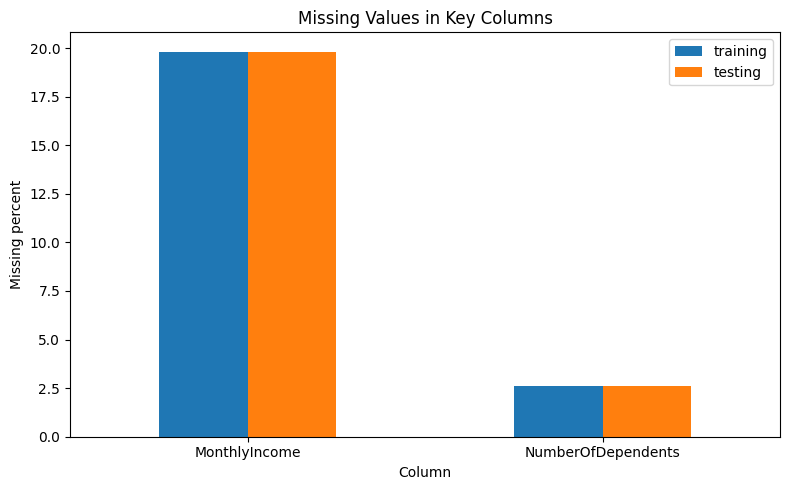

In [8]:
fig_data = pd.DataFrame({
    "training": train_df[focus_cols].isna().mean() * 100,
    "testing": test_df[focus_cols].isna().mean() * 100,
})

ax = fig_data.plot(kind="bar", figsize=(8, 5))
ax.set_title("Missing Values in Key Columns")
ax.set_ylabel("Missing percent")
ax.set_xlabel("Column")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "missing_values_key_columns.png", dpi=150)
plt.show()

In [9]:
pattern_train = train_df[focus_cols].isna().value_counts(dropna=False).rename("rows").reset_index()
pattern_test = test_df[focus_cols].isna().value_counts(dropna=False).rename("rows").reset_index()

display(pattern_train)
display(pattern_test)

,MonthlyIncome,NumberOfDependents,rows
0,False,False,120269
1,True,False,25807
2,True,True,3924


,MonthlyIncome,NumberOfDependents,rows
0,False,False,81400
1,True,False,17477
2,True,True,2626


In [10]:
missing_summary.to_csv(INTERIM_DIR / "missing_value_summary.csv")

report_text = f"""# Missing Value Analysis

## Files Reviewed

- Training rows: {len(train_df):,}
- Testing rows: {len(test_df):,}

## Key Missing Columns

| Column | Training Missing | Training % | Testing Missing | Testing % |
|---|---:|---:|---:|---:|
| MonthlyIncome | {train_df['MonthlyIncome'].isna().sum():,} | {train_df['MonthlyIncome'].isna().mean() * 100:.2f}% | {test_df['MonthlyIncome'].isna().sum():,} | {test_df['MonthlyIncome'].isna().mean() * 100:.2f}% |
| NumberOfDependents | {train_df['NumberOfDependents'].isna().sum():,} | {train_df['NumberOfDependents'].isna().mean() * 100:.2f}% | {test_df['NumberOfDependents'].isna().sum():,} | {test_df['NumberOfDependents'].isna().mean() * 100:.2f}% |

## Decision

Use model-based imputation with missing indicators. Do not use global mean filling as the final imputation strategy.
"""

(REPORTS_DIR / "missing_value_analysis.md").write_text(report_text, encoding="utf-8")
print("Saved missing-value CSV, report, and figure.")

Saved missing-value CSV, report, and figure.
